In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [4]:
from src import config
from feature_extraction import extract_mel_spectrogram

In [5]:
import librosa, matplotlib.pyplot as plt

In [6]:
RAW_AUDIO_DIR_EN = Path("../../data/audio/en_clips")
RAW_AUDIO_DIR_BN = Path("../../data/audio/bn_clips")

In [14]:
en_audio_path = RAW_AUDIO_DIR_EN / "MT0016971741_clip_3.wav"
bn_audio_path = RAW_AUDIO_DIR_BN / "1143_7.wav"

In [15]:
y_en, sr = librosa.load(en_audio_path, sr=config.SAMPLE_RATE)
y_bn, sr = librosa.load(bn_audio_path, sr=config.SAMPLE_RATE)

In [16]:
en_y_spec = extract_mel_spectrogram(audio_path=en_audio_path)
bn_y_spec = extract_mel_spectrogram(audio_path=bn_audio_path)

In [17]:
en_y_spec

array([[-32.7354  , -42.560497, -45.25566 , ..., -10.094734, -10.351135,
        -15.185566],
       [-31.030964, -41.00475 , -43.281174, ..., -23.67273 , -23.455555,
        -24.04468 ],
       [-21.94569 , -22.106781, -25.179409, ..., -25.662006, -27.865963,
        -28.35044 ],
       ...,
       [-77.340385, -80.      , -80.      , ..., -60.49013 , -80.      ,
        -66.36549 ],
       [-77.90998 , -80.      , -80.      , ..., -60.176254, -80.      ,
        -67.02565 ],
       [-78.22735 , -80.      , -80.      , ..., -59.9802  , -80.      ,
        -67.39709 ]], shape=(64, 91), dtype=float32)

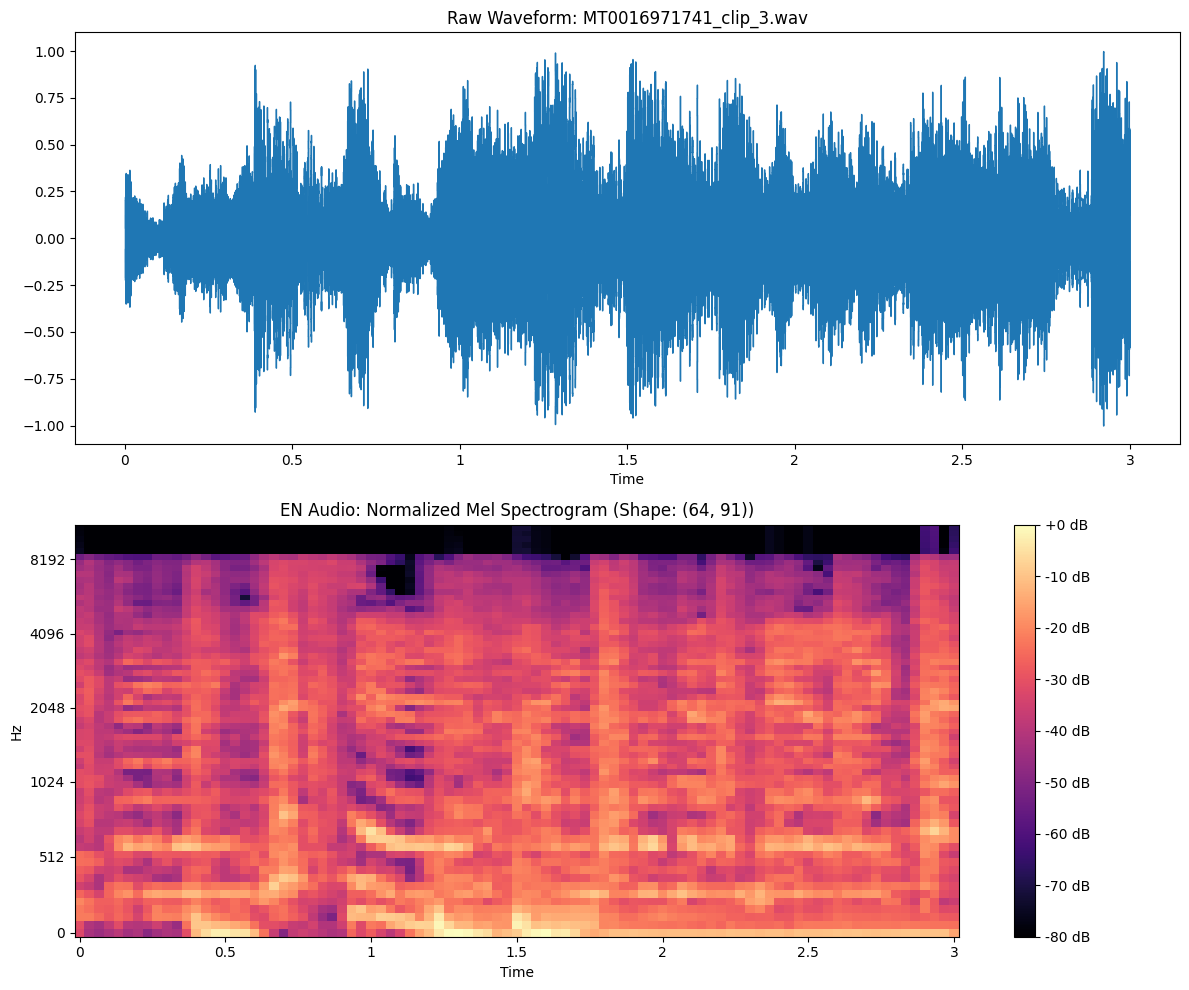

In [10]:
# EN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {en_audio_path.name}")

img = librosa.display.specshow(
    en_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"EN Audio: Normalized Mel Spectrogram (Shape: {en_y_spec.shape})")

plt.tight_layout()
plt.show()

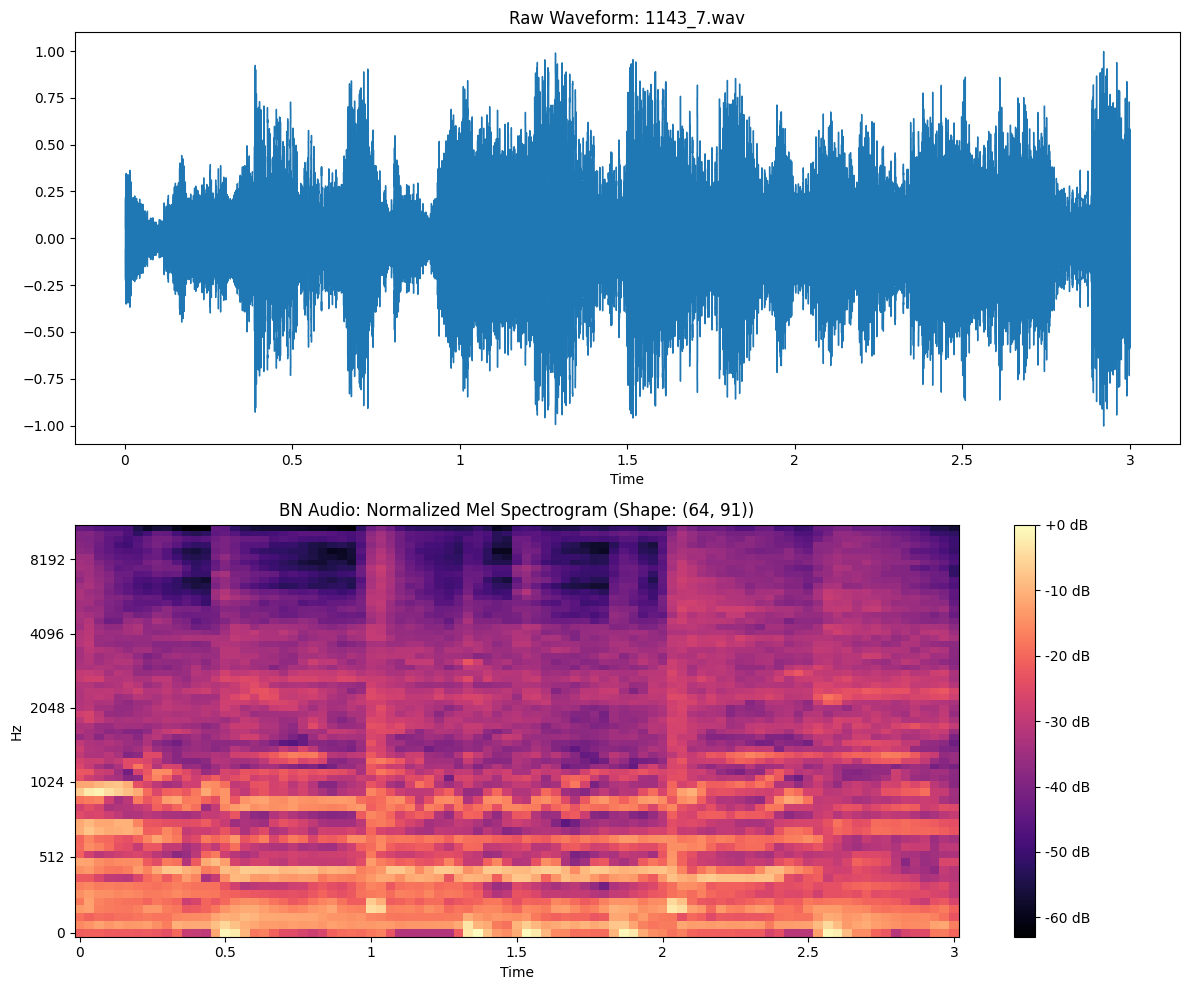

In [18]:
# BN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {bn_audio_path.name}")

img = librosa.display.specshow(
    bn_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"BN Audio: Normalized Mel Spectrogram (Shape: {bn_y_spec.shape})")

plt.tight_layout()
plt.show()